<a href="https://colab.research.google.com/github/zmohaghegh/Retail-Sales-Exploratory-Data-Analysis/blob/main/Retail_Sales_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Head ---
  Transaction_Date Product_Category  Sales_Amount  Quantity Region    Month
0       2023-01-01       Home Decor    352.099240         2  North  2023-01
1       2023-01-02        Groceries    272.687220         6  North  2023-01
2       2023-01-03      Electronics    161.668532         5  South  2023-01
3       2023-01-04       Home Decor    408.759560         9   West  2023-01
4       2023-01-05       Home Decor    345.518275         5   East  2023-01

--- Summary Statistics ---
          Transaction_Date  Sales_Amount    Quantity
count                 1000   1000.000000  1000.00000
mean   2024-05-14 12:00:00    254.879831     5.03600
min    2023-01-01 00:00:00     12.269691     1.00000
25%    2023-09-07 18:00:00    126.097028     3.00000
50%    2024-05-14 12:00:00    255.265375     5.00000
75%    2025-01-19 06:00:00    377.367206     7.00000
max    2025-09-26 00:00:00    499.861660     9.00000
std                    NaN    142.982095     2.54385


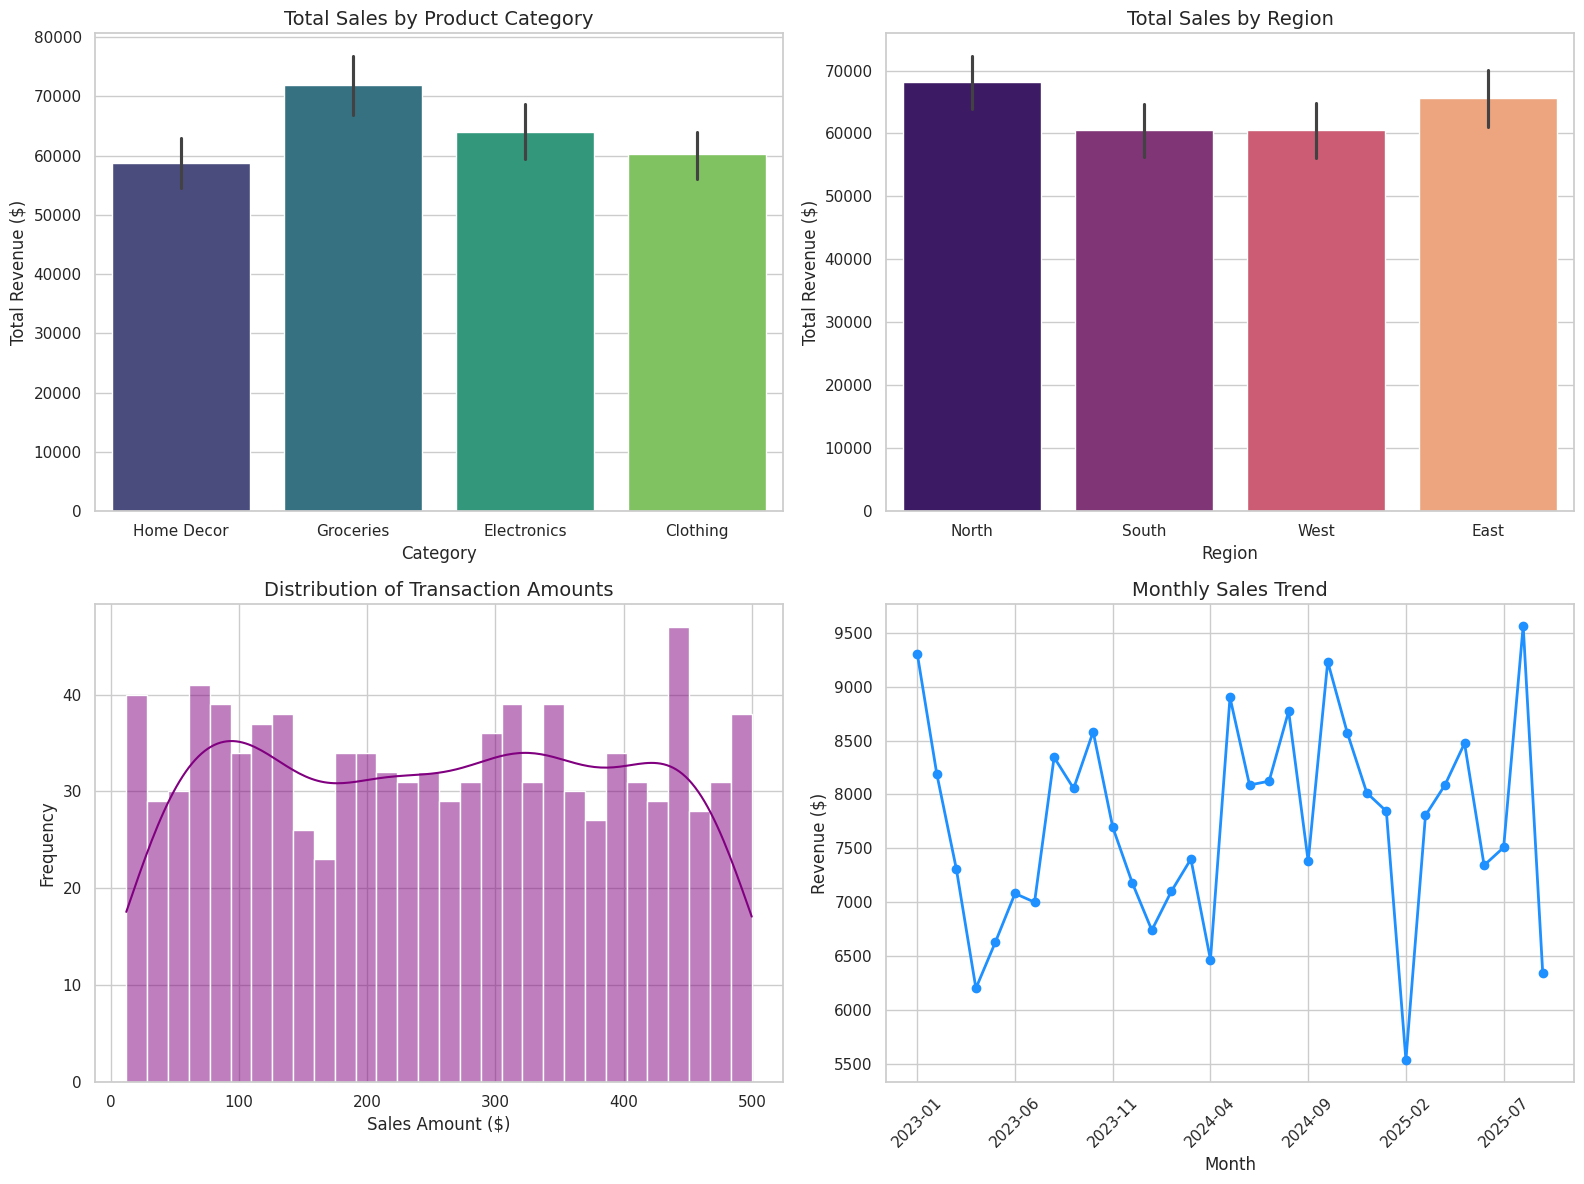

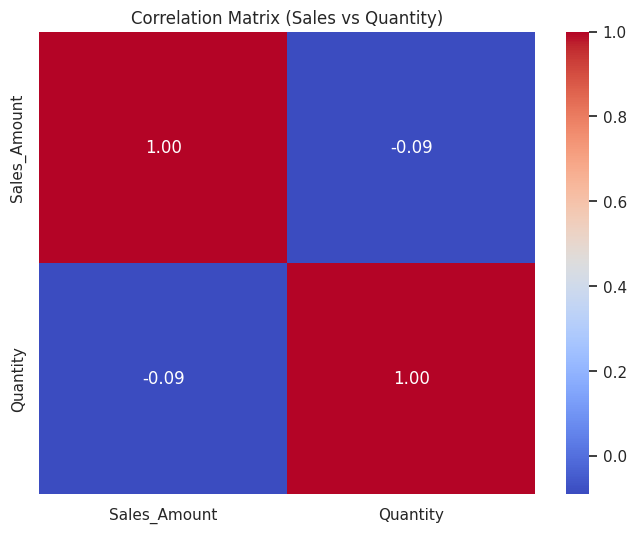


--- Key Business Insights ---
1. Top Performing Category: Groceries
2. Most Profitable Region: North
3. Average Transaction Value: $254.88


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# غیرفعال کردن هشدارهای غیرضروری برای تمیزی خروجی
warnings.filterwarnings('ignore')

# --- 1. DATA GENERATION (Simulating Retail Sales) ---
# ایجاد یک دیتاست فرضی برای تحلیل فروش
np.random.seed(42)
data_size = 1000

data = {
    'Transaction_Date': pd.date_range(start='2023-01-01', periods=data_size, freq='D'),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home Decor', 'Groceries'], data_size),
    'Sales_Amount': np.random.uniform(10, 500, data_size),
    'Quantity': np.random.randint(1, 10, data_size),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], data_size)
}

df = pd.DataFrame(data)
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

# --- 2. DATA OVERVIEW ---
print("--- Dataset Head ---")
print(df.head())
print("\n--- Summary Statistics ---")
print(df.describe())

# --- 3. VISUALIZATION (EDA) ---
# تنظیم استایل نمودارها
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# الف) فروش کل بر اساس دسته‌بندی محصولات
plt.subplot(2, 2, 1)
sns.barplot(x='Product_Category', y='Sales_Amount', data=df, estimator=sum, hue='Product_Category', palette='viridis', legend=False)
plt.title('Total Sales by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')

# ب) عملکرد مناطق مختلف فروش
plt.subplot(2, 2, 2)
sns.barplot(x='Region', y='Sales_Amount', data=df, estimator=sum, hue='Region', palette='magma', legend=False)
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Revenue ($)')

# ج) توزیع مبالغ تراکنش‌ها (هیستوگرام)
plt.subplot(2, 2, 3)
sns.histplot(df['Sales_Amount'], bins=30, kde=True, color='purple')
plt.title('Distribution of Transaction Amounts', fontsize=14)
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')

# د) روند فروش ماهانه (سری زمانی)
plt.subplot(2, 2, 4)
monthly_sales = df.groupby('Month')['Sales_Amount'].sum()
monthly_sales.plot(kind='line', marker='o', color='dodgerblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 4. CORRELATION ANALYSIS ---
plt.figure(figsize=(8, 6))
# انتخاب ستون‌های عددی برای ماتریس همبستگی
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Sales vs Quantity)')
plt.show()

# --- 5. FINAL INSIGHTS ---
print("\n--- Key Business Insights ---")
best_category = df.groupby('Product_Category')['Sales_Amount'].sum().idxmax()
best_region = df.groupby('Region')['Sales_Amount'].sum().idxmax()
print(f"1. Top Performing Category: {best_category}")
print(f"2. Most Profitable Region: {best_region}")
print(f"3. Average Transaction Value: ${df['Sales_Amount'].mean():.2f}")